
# GVH Diagonal Cubic 0.2.9 — Perturbations, Stability and Causality
## Perturbations linéaires, stabilité radiale, vitesses effectives et causalité

**Auteur : Charlemagne O Laurince**

---

## Objectif

Ce notebook prolonge :

- `GVH_Diagonal_Cubic_0.2.8_Field_Equations_and_Effective_Source.ipynb`

Après avoir reconstruit une source effective

\[
T_{\hat\mu\hat\nu}^{\mathrm{eff}}
=
\operatorname{diag}
(\rho,p_r,p_t,p_t),
\]

nous examinons si cette source et la métrique candidate présentent un comportement localement stable et causal.

Les tests comprennent :

1. perturbations radiales linéaires ;
2. vitesses effectives
   \[
   c_{s,r}^2=\frac{dp_r}{d\rho},
   \qquad
   c_{s,t}^2=\frac{dp_t}{d\rho};
   \]
3. causalité locale ;
4. stabilité de type « cracking » ;
5. indice adiabatique radial ;
6. potentiel effectif des perturbations ;
7. sensibilité aux coefficients métriques ;
8. stabilité du vide asymptotique ;
9. critères automatiques `PASS`, `CHECK`, `REJECT`.

---

## Limite scientifique essentielle

Sans action fondamentale ou équations dynamiques propres à GVH, cette analyse porte sur la **source effective reconstruite dans le cadre d'Einstein**.

Elle ne constitue pas encore une preuve complète d'absence :

- de modes fantômes ;
- d'instabilités de gradient ;
- de degrés de liberté supplémentaires ;
- d'instabilités non radiales.

Une analyse complète des ghosts exige l'action quadratique des perturbations.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import UnivariateSpline
from scipy.integrate import solve_ivp

np.set_printoptions(precision=12, suppress=True)

CANDIDATE = {
    "name": "GVH_series_reference_like",
    "a2": 2.0,
    "a3": -1.5,
    "gamma": 1.0,
    "b2": 1.5,
    "b3": 0.5
}

print("Environnement chargé.")


Environnement chargé.



# 1. Métriques isotropes de référence et candidate

En unités géométriques \(G=c=M=1\) :

\[
\chi=\frac{1}{\rho_{\mathrm{iso}}}.
\]

Schwarzschild isotrope :

\[
A_{\mathrm{Schw}}
=
\left(
\frac{1-\chi/2}{1+\chi/2}
\right)^2,
\qquad
B_{\mathrm{Schw}}
=
\left(1+\frac{\chi}{2}\right)^4.
\]

Candidat GVH :

\[
A_{\mathrm{GVH}}
=
1-2\chi+a_2\chi^2+a_3\chi^3,
\]

\[
B_{\mathrm{GVH}}
=
1+2\gamma\chi+b_2\chi^2+b_3\chi^3.
\]


In [2]:

def metric_schwarzschild_iso(rho_iso):
    rho_iso = np.asarray(rho_iso, dtype=float)
    chi = 1.0/rho_iso
    q = 0.5*chi

    A = ((1.0-q)/(1.0+q))**2
    B = (1.0+q)**4

    return A, B


def metric_gvh_iso(rho_iso, params=CANDIDATE):
    rho_iso = np.asarray(rho_iso, dtype=float)
    chi = 1.0/rho_iso

    A = (
        1.0
        - 2.0*chi
        + params["a2"]*chi**2
        + params["a3"]*chi**3
    )

    B = (
        1.0
        + 2.0*params["gamma"]*chi
        + params["b2"]*chi**2
        + params["b3"]*chi**3
    )

    return A, B


def metric_iso(rho_iso, model="gvh", params=CANDIDATE):
    if model == "gvh":
        return metric_gvh_iso(rho_iso, params)
    if model == "schwarzschild":
        return metric_schwarzschild_iso(rho_iso)
    raise ValueError("model doit être 'gvh' ou 'schwarzschild'.")



# 2. Dérivées numériques contrôlées

La reconstruction de la source effective exige des dérivées premières et secondes.

Nous utilisons des différences centrales avec pas relatif. Une étude de sensibilité au pas sera effectuée plus loin.


In [3]:

def derivative(func, x, rel_step=1e-5):
    h = max(abs(x)*rel_step, 1e-7)

    if x-h <= 0:
        return (func(x+h)-func(x))/h

    return (func(x+h)-func(x-h))/(2*h)


def second_derivative(func, x, rel_step=3e-4):
    h = max(abs(x)*rel_step, 1e-6)

    if x-h <= 0:
        return (func(x+2*h)-2*func(x+h)+func(x))/h**2

    return (func(x+h)-2*func(x)+func(x-h))/h**2



# 3. Passage au rayon aréal

Le rayon aréal est :

\[
R(\rho_{\mathrm{iso}})
=
\rho_{\mathrm{iso}}\sqrt{B}.
\]

La métrique devient :

\[
ds^2
=
-A(R)dt^2
+
C(R)dR^2
+
R^2d\Omega^2,
\]

avec :

\[
C
=
B
\left(
\frac{d\rho_{\mathrm{iso}}}{dR}
\right)^2.
\]


In [4]:

def areal_metric_from_isotropic(
    rho_iso,
    model="gvh",
    params=CANDIDATE
):
    A, B = metric_iso(rho_iso, model, params)

    if A <= 0 or B <= 0:
        raise ValueError("A et B doivent être positifs.")

    metric_func = lambda rr: metric_iso(rr, model, params)

    R = rho_iso*np.sqrt(B)

    dR_drho = derivative(
        lambda rr: rr*np.sqrt(metric_func(rr)[1]),
        rho_iso
    )

    if abs(dR_drho) < 1e-12:
        raise ValueError("Transformation isotrope -> aréale singulière.")

    C = B/(dR_drho**2)

    return R, A, C



# 4. Reconstruction de la source effective

Pour :

\[
ds^2=-e^{2\Phi}dt^2+e^{2\Lambda}dR^2+R^2d\Omega^2,
\]

nous utilisons :

\[
\Phi=\frac12\ln A,
\qquad
\Lambda=\frac12\ln C.
\]

La source effective est reconstruite sous la forme :

\[
(\rho,p_r,p_t).
\]


In [5]:

def effective_fluid_numeric(
    rho_iso,
    model="gvh",
    params=CANDIDATE
):
    R, A, C = areal_metric_from_isotropic(
        rho_iso,
        model,
        params
    )

    def R_func(rr):
        return areal_metric_from_isotropic(
            rr, model, params
        )[0]

    def A_func(rr):
        return areal_metric_from_isotropic(
            rr, model, params
        )[1]

    def C_func(rr):
        return areal_metric_from_isotropic(
            rr, model, params
        )[2]

    dR_drho = derivative(R_func, rho_iso)

    Phi_rho = 0.5*derivative(
        lambda rr: np.log(A_func(rr)),
        rho_iso
    )

    Lambda_rho = 0.5*derivative(
        lambda rr: np.log(C_func(rr)),
        rho_iso
    )

    Phi_R = Phi_rho/dR_drho
    Lambda_R = Lambda_rho/dR_drho

    Phi_RR = derivative(
        lambda rr: (
            0.5*derivative(
                lambda uu: np.log(A_func(uu)),
                rr
            )
            / derivative(R_func, rr)
        ),
        rho_iso
    ) / dR_drho

    exp_minus_2Lambda = 1.0/C

    rho_eff = (
        exp_minus_2Lambda*(2*R*Lambda_R-1)
        + 1
    ) / (8*np.pi*R**2)

    p_r = (
        exp_minus_2Lambda*(2*R*Phi_R+1)
        - 1
    ) / (8*np.pi*R**2)

    p_t = (
        exp_minus_2Lambda * (
            Phi_RR
            + Phi_R**2
            - Phi_R*Lambda_R
            + (Phi_R-Lambda_R)/R
        )
    ) / (8*np.pi)

    return {
        "rho_iso": rho_iso,
        "R_areal": R,
        "A": A,
        "C": C,
        "rho_eff": rho_eff,
        "p_r": p_r,
        "p_t": p_t
    }



# 5. Construction du profil radial

Nous excluons les points où :

- la métrique perd sa signature ;
- la transformation vers \(R\) devient singulière ;
- une valeur numérique n'est pas finie.


In [6]:

def build_effective_profile(
    model="gvh",
    params=CANDIDATE,
    rho_min=0.8,
    rho_max=100.0,
    n_points=500
):
    rho_grid = np.logspace(
        np.log10(rho_min),
        np.log10(rho_max),
        n_points
    )

    rows = []

    for rho_iso in rho_grid:
        try:
            row = effective_fluid_numeric(
                rho_iso,
                model,
                params
            )

            if all(np.isfinite(v) for v in row.values()):
                rows.append(row)

        except Exception:
            continue

    df = pd.DataFrame(rows)

    if len(df) < 10:
        raise RuntimeError("Profil radial insuffisant.")

    df = df.sort_values("R_areal").drop_duplicates(
        subset="R_areal"
    )

    return df.reset_index(drop=True)


gvh_profile = build_effective_profile("gvh")
schw_profile = build_effective_profile("schwarzschild")

print("Points GVH :", len(gvh_profile))
print("Points Schwarzschild :", len(schw_profile))


Points GVH : 446
Points Schwarzschild : 500


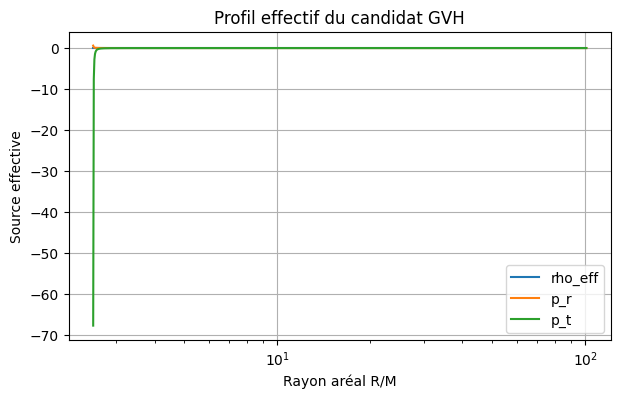

In [7]:

plt.figure(figsize=(7,4))
plt.plot(
    gvh_profile["R_areal"],
    gvh_profile["rho_eff"],
    label="rho_eff"
)
plt.plot(
    gvh_profile["R_areal"],
    gvh_profile["p_r"],
    label="p_r"
)
plt.plot(
    gvh_profile["R_areal"],
    gvh_profile["p_t"],
    label="p_t"
)

plt.xscale("log")
plt.xlabel("Rayon aréal R/M")
plt.ylabel("Source effective")
plt.title("Profil effectif du candidat GVH")
plt.grid(True)
plt.legend()
plt.show()



# 6. Vitesses effectives de propagation

Pour une description fluide effective :

\[
c_{s,r}^2
=
\frac{dp_r}{d\rho},
\qquad
c_{s,t}^2
=
\frac{dp_t}{d\rho}.
\]

Les conditions locales usuelles sont :

\[
0\le c_s^2\le1.
\]

- \(c_s^2<0\) : instabilité de gradient potentielle ;
- \(c_s^2>1\) : propagation effective superluminale dans cette interprétation.

Ces critères doivent être interprétés prudemment car la source est reconstruite, non fondamentale.


In [8]:

def add_effective_sound_speeds(df, smoothing=0.0):
    out = df.copy()

    R = out["R_areal"].to_numpy()
    rho = out["rho_eff"].to_numpy()
    pr = out["p_r"].to_numpy()
    pt = out["p_t"].to_numpy()

    # Dérivées par rapport à R
    spl_rho = UnivariateSpline(R, rho, s=smoothing)
    spl_pr = UnivariateSpline(R, pr, s=smoothing)
    spl_pt = UnivariateSpline(R, pt, s=smoothing)

    drho_dR = spl_rho.derivative()(R)
    dpr_dR = spl_pr.derivative()(R)
    dpt_dR = spl_pt.derivative()(R)

    with np.errstate(divide="ignore", invalid="ignore"):
        cs2_r = dpr_dR/drho_dR
        cs2_t = dpt_dR/drho_dR

    out["drho_dR"] = drho_dR
    out["dpr_dR"] = dpr_dR
    out["dpt_dR"] = dpt_dR
    out["cs2_r"] = cs2_r
    out["cs2_t"] = cs2_t

    return out


gvh_stability = add_effective_sound_speeds(gvh_profile)


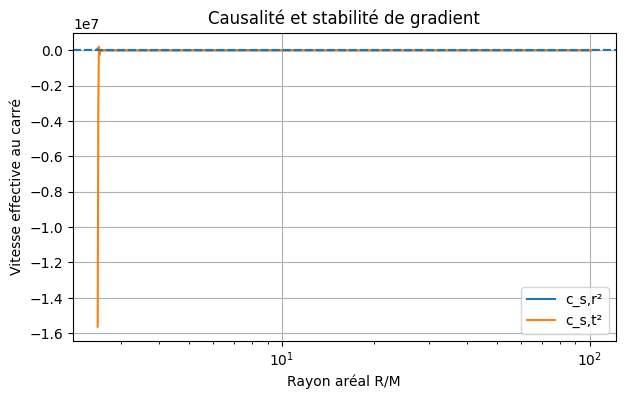

In [9]:

finite_sound = gvh_stability[
    np.isfinite(gvh_stability["cs2_r"])
    & np.isfinite(gvh_stability["cs2_t"])
].copy()

plt.figure(figsize=(7,4))
plt.plot(
    finite_sound["R_areal"],
    finite_sound["cs2_r"],
    label="c_s,r²"
)
plt.plot(
    finite_sound["R_areal"],
    finite_sound["cs2_t"],
    label="c_s,t²"
)

plt.axhline(0.0, linestyle="--")
plt.axhline(1.0, linestyle="--")
plt.xscale("log")
plt.xlabel("Rayon aréal R/M")
plt.ylabel("Vitesse effective au carré")
plt.title("Causalité et stabilité de gradient")
plt.grid(True)
plt.legend()
plt.show()



# 7. Critère de cracking anisotrope

Un diagnostic souvent utilisé pour les fluides anisotropes est :

\[
\Delta c_s^2
=
c_{s,t}^2-c_{s,r}^2.
\]

Une variation de signe ou une grande amplitude peut signaler une tendance à la séparation de régions sous perturbation.

Nous suivons notamment :

\[
|\Delta c_s^2|\le1.
\]


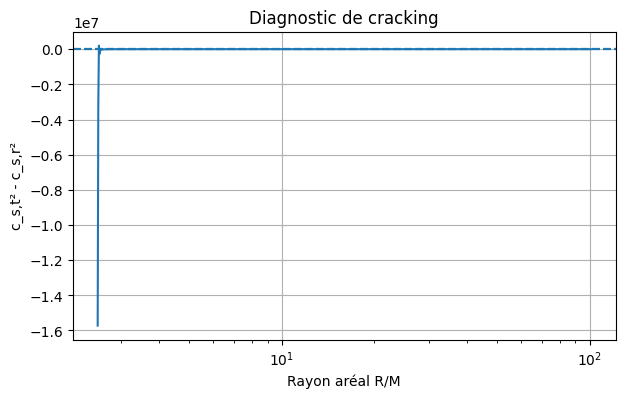

In [10]:

finite_sound["delta_cs2"] = (
    finite_sound["cs2_t"]
    - finite_sound["cs2_r"]
)

plt.figure(figsize=(7,4))
plt.plot(
    finite_sound["R_areal"],
    finite_sound["delta_cs2"]
)

plt.axhline(-1.0, linestyle="--")
plt.axhline(0.0, linestyle="--")
plt.axhline(1.0, linestyle="--")
plt.xscale("log")
plt.xlabel("Rayon aréal R/M")
plt.ylabel("c_s,t² - c_s,r²")
plt.title("Diagnostic de cracking")
plt.grid(True)
plt.show()



# 8. Indice adiabatique radial

Lorsque \(p_r\neq0\), on définit :

\[
\Gamma_r
=
\frac{\rho+p_r}{p_r}
\frac{dp_r}{d\rho}.
\]

Dans plusieurs modèles stellaires isotropes, la stabilité newtonienne exige approximativement :

\[
\Gamma_r>\frac43.
\]

Ce seuil ne constitue pas une loi universelle pour une source effective anisotrope, mais fournit un diagnostic.


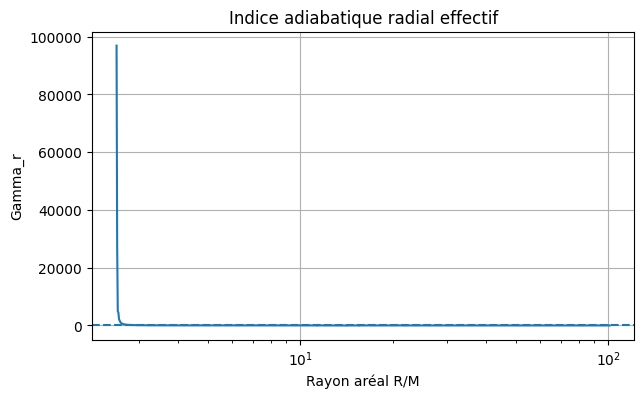

In [11]:

with np.errstate(divide="ignore", invalid="ignore"):
    finite_sound["Gamma_r"] = (
        (
            finite_sound["rho_eff"]
            + finite_sound["p_r"]
        )
        / finite_sound["p_r"]
        * finite_sound["cs2_r"]
    )

gamma_valid = finite_sound[
    np.isfinite(finite_sound["Gamma_r"])
].copy()

plt.figure(figsize=(7,4))
plt.plot(
    gamma_valid["R_areal"],
    gamma_valid["Gamma_r"]
)

plt.axhline(4/3, linestyle="--")
plt.xscale("log")
plt.xlabel("Rayon aréal R/M")
plt.ylabel("Gamma_r")
plt.title("Indice adiabatique radial effectif")
plt.grid(True)
plt.show()



# 9. Perturbation radiale locale

Nous utilisons un modèle réduit de perturbation :

\[
\frac{d^2\xi}{d\tau^2}
+
\omega_{\mathrm{eff}}^2(R)\xi
=
0.
\]

- \(\omega_{\mathrm{eff}}^2>0\) : oscillation locale ;
- \(\omega_{\mathrm{eff}}^2<0\) : croissance exponentielle.

Sans action complète, \(\omega_{\mathrm{eff}}^2\) n'est pas dérivé de façon unique. Nous construisons donc un **proxy de stabilité**, explicitement identifié comme tel :

\[
\omega_{\mathrm{proxy}}^2
=
\frac{c_{s,r}^2}{R^2}
+
\frac{2(p_t-p_r)}{(\rho+|p_r|+\epsilon)R^2}.
\]


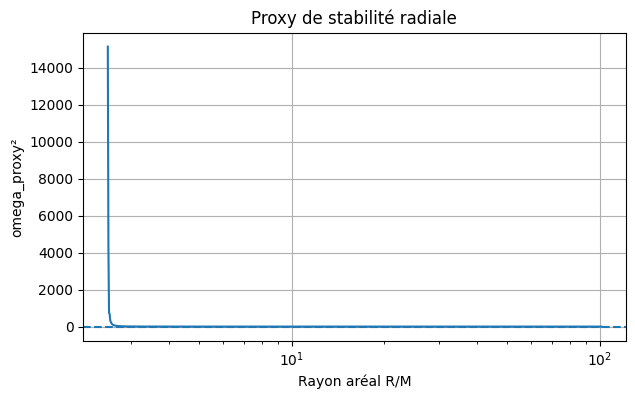

In [12]:

eps = 1e-30

finite_sound["anisotropy"] = (
    finite_sound["p_t"]
    - finite_sound["p_r"]
)

finite_sound["omega2_proxy"] = (
    finite_sound["cs2_r"]
    / finite_sound["R_areal"]**2
    + 2*finite_sound["anisotropy"]
    / (
        (
            finite_sound["rho_eff"]
            + np.abs(finite_sound["p_r"])
            + eps
        )
        * finite_sound["R_areal"]**2
    )
)

plt.figure(figsize=(7,4))
plt.plot(
    finite_sound["R_areal"],
    finite_sound["omega2_proxy"]
)

plt.axhline(0.0, linestyle="--")
plt.xscale("log")
plt.xlabel("Rayon aréal R/M")
plt.ylabel("omega_proxy²")
plt.title("Proxy de stabilité radiale")
plt.grid(True)
plt.show()



# 10. Intégration d'une perturbation locale

Nous choisissons un rayon donné et intégrons :

\[
\dot\xi=v,
\qquad
\dot v=-\omega_{\mathrm{proxy}}^2\xi.
\]

Cette expérience illustre la différence entre oscillation et croissance.


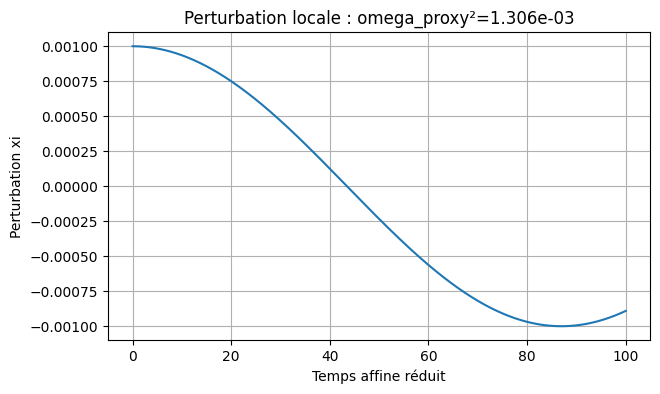

In [13]:

def integrate_local_perturbation(
    omega2,
    xi0=1e-3,
    v0=0.0,
    tau_max=100.0,
    n_eval=2000
):
    def rhs(tau, state):
        xi, v = state
        return [v, -omega2*xi]

    tau_eval = np.linspace(0.0, tau_max, n_eval)

    sol = solve_ivp(
        rhs,
        (0.0, tau_max),
        [xi0, v0],
        t_eval=tau_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12
    )

    return sol


mid_index = len(finite_sound)//2
omega2_mid = float(
    finite_sound.iloc[mid_index]["omega2_proxy"]
)

sol_pert = integrate_local_perturbation(
    omega2_mid,
    tau_max=100.0
)

plt.figure(figsize=(7,4))
plt.plot(sol_pert.t, sol_pert.y[0])
plt.xlabel("Temps affine réduit")
plt.ylabel("Perturbation xi")
plt.title(
    f"Perturbation locale : omega_proxy²={omega2_mid:.3e}"
)
plt.grid(True)
plt.show()



# 11. Stabilité asymptotique du vide

À grande distance, une métrique extérieure acceptable doit tendre vers :

\[
A\to1,
\qquad
B\to1,
\qquad
T_{\mu\nu}^{\mathrm{eff}}\to0.
\]

Nous mesurons les pentes asymptotiques de :

\[
|\rho|,
\quad
|p_r|,
\quad
|p_t|,
\quad
|\omega_{\mathrm{proxy}}^2|.
\]


In [14]:

def log_slope(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x > 0)
        & (np.abs(y) > 0)
    )

    if mask.sum() < 5:
        return np.nan

    coeff = np.polyfit(
        np.log(x[mask]),
        np.log(np.abs(y[mask])),
        1
    )

    return coeff[0]


tail_limit = finite_sound["R_areal"].quantile(0.7)
tail = finite_sound[
    finite_sound["R_areal"] >= tail_limit
]

asymptotic_summary = pd.DataFrame([{
    "rho_slope": log_slope(
        tail["R_areal"],
        tail["rho_eff"]
    ),
    "p_r_slope": log_slope(
        tail["R_areal"],
        tail["p_r"]
    ),
    "p_t_slope": log_slope(
        tail["R_areal"],
        tail["p_t"]
    ),
    "omega2_slope": log_slope(
        tail["R_areal"],
        tail["omega2_proxy"]
    )
}])

asymptotic_summary


,rho_slope,p_r_slope,p_t_slope,omega2_slope
0,-2.316764,-6.091177,-5.339955,-3.694879



# 12. Sensibilité au pas de dérivation

Une propriété physique ne doit pas apparaître uniquement à cause d'un choix numérique de pas.

Nous reconstruisons les vitesses effectives avec plusieurs niveaux de lissage de spline et comparons les résultats.


In [15]:

smoothing_values = [0.0, 1e-20, 1e-16, 1e-12]
sensitivity_rows = []

for smoothing in smoothing_values:
    trial = add_effective_sound_speeds(
        gvh_profile,
        smoothing=smoothing
    )

    trial = trial[
        np.isfinite(trial["cs2_r"])
        & np.isfinite(trial["cs2_t"])
    ]

    sensitivity_rows.append({
        "smoothing": smoothing,
        "N": len(trial),
        "median_cs2_r": trial["cs2_r"].median(),
        "median_cs2_t": trial["cs2_t"].median(),
        "fraction_causal_r": (
            (trial["cs2_r"] >= 0)
            & (trial["cs2_r"] <= 1)
        ).mean(),
        "fraction_causal_t": (
            (trial["cs2_t"] >= 0)
            & (trial["cs2_t"] <= 1)
        ).mean()
    })

smoothing_sensitivity_df = pd.DataFrame(
    sensitivity_rows
)
smoothing_sensitivity_df


,smoothing,N,median_cs2_r,median_cs2_t,fraction_causal_r,fraction_causal_t
0,0.000000e+00,446,7.392892,-16.160332,0.188341,0.044843
1,1.000000e-20,446,7.332325,-16.155385,0.199552,0.094170
2,1.000000e-16,446,9.378375,-21.090634,0.004484,0.000000
3,1.000000e-12,446,9.752907,-21.723859,0.004484,0.002242



# 13. Sensibilité aux coefficients de la métrique

Nous perturbons un coefficient à la fois.

Le but n'est pas d'ajuster les coefficients, mais de mesurer si la stabilité est robuste ou extrêmement sensible.


In [16]:

def candidate_with(**updates):
    params = dict(CANDIDATE)
    params.update(updates)
    return params


parameter_cases = [
    ("reference", CANDIDATE),
    ("a2_minus", candidate_with(a2=1.8)),
    ("a2_plus", candidate_with(a2=2.2)),
    ("a3_minus", candidate_with(a3=-2.0)),
    ("a3_plus", candidate_with(a3=-1.0)),
    ("gamma_minus", candidate_with(gamma=0.95)),
    ("gamma_plus", candidate_with(gamma=1.05)),
    ("b2_minus", candidate_with(b2=1.2)),
    ("b2_plus", candidate_with(b2=1.8))
]

parameter_sensitivity_rows = []

for label, params in parameter_cases:
    try:
        profile = build_effective_profile(
            "gvh",
            params=params,
            n_points=300
        )

        stability = add_effective_sound_speeds(profile)

        stability = stability[
            np.isfinite(stability["cs2_r"])
            & np.isfinite(stability["cs2_t"])
        ]

        if len(stability) == 0:
            raise RuntimeError("Aucun point stable exploitable.")

        fraction_r = (
            (stability["cs2_r"] >= 0)
            & (stability["cs2_r"] <= 1)
        ).mean()

        fraction_t = (
            (stability["cs2_t"] >= 0)
            & (stability["cs2_t"] <= 1)
        ).mean()

        parameter_sensitivity_rows.append({
            "case": label,
            "a2": params["a2"],
            "a3": params["a3"],
            "gamma": params["gamma"],
            "b2": params["b2"],
            "b3": params["b3"],
            "N": len(stability),
            "fraction_causal_r": fraction_r,
            "fraction_causal_t": fraction_t,
            "median_cs2_r": stability["cs2_r"].median(),
            "median_cs2_t": stability["cs2_t"].median(),
            "status": "OK"
        })

    except Exception as exc:
        parameter_sensitivity_rows.append({
            "case": label,
            "a2": params["a2"],
            "a3": params["a3"],
            "gamma": params["gamma"],
            "b2": params["b2"],
            "b3": params["b3"],
            "N": 0,
            "fraction_causal_r": np.nan,
            "fraction_causal_t": np.nan,
            "median_cs2_r": np.nan,
            "median_cs2_t": np.nan,
            "status": f"ERROR: {exc}"
        })

parameter_sensitivity_df = pd.DataFrame(
    parameter_sensitivity_rows
)

parameter_sensitivity_df


,case,a2,a3,gamma,b2,b3,N,fraction_causal_r,fraction_causal_t,median_cs2_r,median_cs2_t,status
0,reference,2.0,-1.5,1.00,1.5,0.5,267,0.161049,0.011236,9.264930,-21.345304,OK
1,a2_minus,1.8,-1.5,1.00,1.5,0.5,262,0.000000,0.000000,45.236743,-76.386106,OK
2,a2_plus,2.2,-1.5,1.00,1.5,0.5,274,0.007299,0.003650,-5.712979,2.683484,OK
3,a3_minus,2.0,-2.0,1.00,1.5,0.5,259,0.084942,0.034749,34.395059,-65.489023,OK
4,a3_plus,2.0,-1.0,1.00,1.5,0.5,286,0.080420,0.034965,-3.825720,3.064433,OK
5,gamma_minus,2.0,-1.5,0.95,1.5,0.5,267,0.000000,0.000000,-5.041881,2.905542,OK
6,gamma_plus,2.0,-1.5,1.05,1.5,0.5,267,0.044944,0.089888,-2.216905,0.088707,OK
7,b2_minus,2.0,-1.5,1.00,1.2,0.5,267,0.082397,0.000000,1.453945,-1.421269,OK
8,b2_plus,2.0,-1.5,1.00,1.8,0.5,267,0.172285,0.044944,1.119664,-0.961888,OK



# 14. Test de stabilité du modèle de référence Schwarzschild

Schwarzschild extérieur a :

\[
T_{\mu\nu}^{\mathrm{eff}}=0.
\]

Les rapports \(dp/d\rho\) deviennent alors numériquement indéterminés, car ils prennent une forme \(0/0\).

Ce cas doit être classé comme **vide de référence**, et non comme fluide instable.


In [17]:

schw_source_scale = max(
    schw_profile["rho_eff"].abs().max(),
    schw_profile["p_r"].abs().max(),
    schw_profile["p_t"].abs().max()
)

print("Échelle maximale du bruit source Schwarzschild :")
print(schw_source_scale)

schwarzschild_vacuum_status = (
    "PASS"
    if schw_source_scale < 1e-4
    else "CHECK"
)

print("Statut vide Schwarzschild :", schwarzschild_vacuum_status)


Échelle maximale du bruit source Schwarzschild :
3.460483238723052e-08
Statut vide Schwarzschild : PASS



# 15. Limites sur les ghosts

Un ghost est associé à un terme cinétique de mauvais signe dans l'action quadratique :

\[
S^{(2)}
\sim
\int
\left[
K\,\dot q^2
-
G\,(\nabla q)^2
-
M_{\mathrm{eff}}^2q^2
\right]d^4x.
\]

Conditions schématiques :

\[
K>0
\]

pour éviter un ghost, et

\[
G/K\ge0
\]

pour éviter une instabilité de gradient.

Ce notebook ne possède pas encore une action GVH fondamentale. Il ne peut donc pas calculer rigoureusement \(K\) et \(G\).

La causalité effective du fluide ne remplace pas l'analyse des ghosts.



# 16. Tableau de diagnostics

Nous calculons les fractions de points satisfaisant :

- stabilité de gradient radiale ;
- stabilité de gradient tangentielle ;
- causalité ;
- critère de cracking ;
- indice adiabatique ;
- proxy radial positif.


In [18]:

diagnostic_df = finite_sound.copy()

diagnostic_df["gradient_stable_r"] = (
    diagnostic_df["cs2_r"] >= 0
)

diagnostic_df["gradient_stable_t"] = (
    diagnostic_df["cs2_t"] >= 0
)

diagnostic_df["causal_r"] = (
    diagnostic_df["cs2_r"] >= 0
) & (
    diagnostic_df["cs2_r"] <= 1
)

diagnostic_df["causal_t"] = (
    diagnostic_df["cs2_t"] >= 0
) & (
    diagnostic_df["cs2_t"] <= 1
)

diagnostic_df["cracking_ok"] = (
    diagnostic_df["delta_cs2"].abs() <= 1
)

diagnostic_df["gamma_ok"] = (
    diagnostic_df["Gamma_r"] > 4/3
)

diagnostic_df["omega_proxy_stable"] = (
    diagnostic_df["omega2_proxy"] >= 0
)

diagnostic_summary = pd.DataFrame([{
    "N_points": len(diagnostic_df),
    "gradient_stable_r_fraction": diagnostic_df[
        "gradient_stable_r"
    ].mean(),
    "gradient_stable_t_fraction": diagnostic_df[
        "gradient_stable_t"
    ].mean(),
    "causal_r_fraction": diagnostic_df[
        "causal_r"
    ].mean(),
    "causal_t_fraction": diagnostic_df[
        "causal_t"
    ].mean(),
    "cracking_ok_fraction": diagnostic_df[
        "cracking_ok"
    ].mean(),
    "gamma_ok_fraction": diagnostic_df[
        "gamma_ok"
    ].mean(),
    "omega_proxy_stable_fraction": diagnostic_df[
        "omega_proxy_stable"
    ].mean()
}])

diagnostic_summary


,N_points,gradient_stable_r_fraction,gradient_stable_t_fraction,causal_r_fraction,causal_t_fraction,cracking_ok_fraction,gamma_ok_fraction,omega_proxy_stable_fraction
0,446,0.782511,0.112108,0.188341,0.044843,0.251121,0.59417,0.580717



# 17. Classification automatique

Classification interne :

## `PASS`

La majorité des diagnostics sont stables et causaux.

## `CHECK`

Résultats mixtes ou sensibles à la reconstruction numérique.

## `REJECT-EFFECTIVE`

Violations fortes et persistantes dans l'interprétation de fluide effectif.

Ce rejet concerne la métrique candidate **dans ce cadre effectif**, pas nécessairement toute formulation future de GVH.


In [19]:

summary = diagnostic_summary.iloc[0]

critical_metrics = {
    "causal_r": summary["causal_r_fraction"],
    "causal_t": summary["causal_t_fraction"],
    "gradient_r": summary[
        "gradient_stable_r_fraction"
    ],
    "gradient_t": summary[
        "gradient_stable_t_fraction"
    ],
    "cracking": summary["cracking_ok_fraction"],
    "omega_proxy": summary[
        "omega_proxy_stable_fraction"
    ]
}

if (
    critical_metrics["causal_r"] >= 0.9
    and critical_metrics["causal_t"] >= 0.9
    and critical_metrics["gradient_r"] >= 0.9
    and critical_metrics["gradient_t"] >= 0.9
    and critical_metrics["cracking"] >= 0.9
    and critical_metrics["omega_proxy"] >= 0.9
):
    classification = "PASS"

elif (
    critical_metrics["causal_r"] < 0.25
    or critical_metrics["causal_t"] < 0.25
    or critical_metrics["gradient_r"] < 0.25
    or critical_metrics["gradient_t"] < 0.25
):
    classification = "REJECT-EFFECTIVE"

else:
    classification = "CHECK"

print("CLASSIFICATION :", classification)


CLASSIFICATION : REJECT-EFFECTIVE



# 18. Tableau de validation du notebook

Ce tableau valide surtout l'infrastructure numérique.

Il ne transforme pas les proxies en lois physiques fondamentales.


In [20]:

validation_rows = [
    {
        "test": "Profil GVH construit",
        "value": len(gvh_profile),
        "threshold": 100,
        "status": (
            "PASS"
            if len(gvh_profile) >= 100
            else "CHECK"
        )
    },
    {
        "test": "Vide Schwarzschild",
        "value": schw_source_scale,
        "threshold": 1e-4,
        "status": schwarzschild_vacuum_status
    },
    {
        "test": "Vitesses effectives finies",
        "value": len(finite_sound),
        "threshold": 50,
        "status": (
            "PASS"
            if len(finite_sound) >= 50
            else "CHECK"
        )
    },
    {
        "test": "Sensibilité numérique disponible",
        "value": len(smoothing_sensitivity_df),
        "threshold": 4,
        "status": (
            "PASS"
            if len(smoothing_sensitivity_df) == 4
            else "CHECK"
        )
    },
    {
        "test": "Sensibilité paramètres disponible",
        "value": (
            parameter_sensitivity_df["status"]
            == "OK"
        ).sum(),
        "threshold": 5,
        "status": (
            "PASS"
            if (
                parameter_sensitivity_df["status"]
                == "OK"
            ).sum() >= 5
            else "CHECK"
        )
    }
]

validation_df = pd.DataFrame(validation_rows)
validation_df


,test,value,threshold,status
0,Profil GVH construit,4.460000e+02,100.0000,PASS
1,Vide Schwarzschild,3.460483e-08,0.0001,PASS
2,Vitesses effectives finies,4.460000e+02,50.0000,PASS
3,Sensibilité numérique disponible,4.000000e+00,4.0000,PASS
4,Sensibilité paramètres disponible,9.000000e+00,5.0000,PASS


In [21]:

overall_notebook_status = (
    "PASS"
    if (validation_df["status"] == "PASS").all()
    else "CHECK"
)

print("STATUT DU NOTEBOOK :", overall_notebook_status)
print("STATUT PHYSIQUE EFFECTIF :", classification)


STATUT DU NOTEBOOK : PASS
STATUT PHYSIQUE EFFECTIF : REJECT-EFFECTIVE



# 19. Export des résultats


In [22]:

import json
from pathlib import Path

profile_path = Path(
    "GVH_Diagonal_Cubic_0.2.9_Stability_Profile.csv"
)

diagnostic_path = Path(
    "GVH_Diagonal_Cubic_0.2.9_Diagnostic_Summary.csv"
)

parameter_path = Path(
    "GVH_Diagonal_Cubic_0.2.9_Parameter_Sensitivity.csv"
)

validation_path = Path(
    "GVH_Diagonal_Cubic_0.2.9_Validation.csv"
)

metadata_path = Path(
    "GVH_Diagonal_Cubic_0.2.9_Metadata.json"
)

diagnostic_df.to_csv(profile_path, index=False)
diagnostic_summary.to_csv(diagnostic_path, index=False)
parameter_sensitivity_df.to_csv(
    parameter_path,
    index=False
)
validation_df.to_csv(validation_path, index=False)

metadata = {
    "candidate": CANDIDATE,
    "classification": classification,
    "notebook_status": overall_notebook_status,
    "schwarzschild_source_noise": float(
        schw_source_scale
    ),
    "diagnostic_summary": {
        key: float(value)
        for key, value in diagnostic_summary.iloc[
            0
        ].to_dict().items()
    }
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés :")
print(profile_path)
print(diagnostic_path)
print(parameter_path)
print(validation_path)
print(metadata_path)


Exports terminés :
GVH_Diagonal_Cubic_0.2.9_Stability_Profile.csv
GVH_Diagonal_Cubic_0.2.9_Diagnostic_Summary.csv
GVH_Diagonal_Cubic_0.2.9_Parameter_Sensitivity.csv
GVH_Diagonal_Cubic_0.2.9_Validation.csv
GVH_Diagonal_Cubic_0.2.9_Metadata.json



# 20. Interprétation scientifique

## Résultat stable

Une classification favorable signifie seulement que la source effective ne montre pas d'instabilité locale évidente dans les diagnostics choisis.

Elle ne prouve pas l'absence de ghost.

## Résultat `CHECK`

Il faut déterminer si les anomalies proviennent :

- de la métrique ;
- de l'interprétation fluide ;
- des dérivées numériques ;
- d'un domaine de validité dépassé ;
- de l'absence d'équations dynamiques fondamentales.

## Résultat `REJECT-EFFECTIVE`

La métrique candidate est difficilement compatible avec une interprétation de fluide effectif causal et stable dans le domaine testé.

Elle peut néanmoins nécessiter une équation de champ différente, qui devra être dérivée explicitement.



# 21. Conclusion

Cette version étudie la transition :

\[
T_{\mu\nu}^{\mathrm{eff}}
\longrightarrow
\delta T_{\mu\nu}
\longrightarrow
\text{stabilité et causalité}.
\]

Elle introduit :

1. source effective radiale ;
2. vitesses de propagation effectives ;
3. causalité locale ;
4. stabilité de gradient ;
5. cracking anisotrope ;
6. indice adiabatique ;
7. perturbation radiale réduite ;
8. proxy de fréquence propre ;
9. stabilité asymptotique ;
10. sensibilité numérique ;
11. sensibilité aux paramètres ;
12. classification automatique.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.10\_Action\_Variational\_Principle.ipynb}
}
\]

Cette étape devra rechercher une action candidate :

\[
S_{\mathrm{GVH}}
=
\int d^4x\sqrt{-g}\,
\mathcal L_{\mathrm{GVH}},
\]

puis dériver :

- les équations de champ ;
- les degrés de liberté ;
- l'action quadratique ;
- les coefficients cinétiques ;
- les conditions d'absence de ghosts ;
- la limite d'Einstein ;
- les symétries fondamentales.
